# 🧭 Proceso de Análisis de Asimilación de Datos

Este flujo resume todas las etapas clave, desde la generación de simulaciones hasta la evaluación cuantitativa de sus resultados.

---

## 🔹 1. Simulación base (sin asimilación)
- Se realiza una simulación de referencia en malla **25×25** sin aplicar ningún método de asimilación.
- Esta simulación sirve como **comparación base**.

---

## 🔹 2. Simulación de alta resolución (referencia “real”)
- Simulación en malla **800×800**, considerada como la “verdad física”.
- Sirve como **referencia para evaluar el error (RMSE)** de las simulaciones con asimilación.

---

## 🔹 3. Asimilación de datos

Se ejecutan múltiples simulaciones aplicando distintos métodos:

### Métodos:
- `nudging`
- `kf` (Kalman Filter)
- `enkf` (Ensemble Kalman Filter)
- `4dvar` (4D-Var)

### Configuraciones:
- **Variables observadas**: `T`, `p`, `tau`, `T,p`, `T,tau`, `T,p,tau`
- **Número de sensores**: 5, 10, 20
- **Frecuencia de observación**: cada 70, 150 o 300 pasos

Cada simulación se guarda como `.pkl` en `DA/25x25/`, codificando su configuración en el nombre.

---

## 🔹 4. Contenido de archivos `.pkl` de simulación

Cada archivo contiene:
- `"T_history"`, `"p_history"`, `"tau_history"`: historia temporal por variable
- `"u_history"`, `"v_history"`: velocidades
- `"X_star"`, `"Y_star"`: malla espacial
- `"params"`: parámetros de configuración
- `"asimilacion_time"`: tiempo total de asimilación

---

## 🔹 5. Interpolación de la referencia (800×800 → 25×25)

Se interpolan las variables de la referencia de alta resolución para compararlas en la misma malla 25×25 que las simulaciones asimiladas.

Se usa `scipy.interpolate.RegularGridInterpolator`.

---

## 🔹 6. Normalización de datos

Se normalizan las variables `T` y `p` para evitar diferencias de escala:

### Normalización global:
\[
f_\text{norm} = \frac{f - \min(f)}{\max(f) - \min(f)}
\]

- Aplicada sobre **todos los frames** de una variable
- Asegura que todas las comparaciones estén en rango `[0, 1]`

---

## 🔹 7. Cálculo de error (RMSE)

Se usa el Error Cuadrático Medio para medir la diferencia respecto a la referencia:

\[
\text{RMSE} = \sqrt{ \frac{1}{N} \sum_{i=1}^{N} (f_i^\text{sim} - f_i^\text{ref})^2 }
\]

- Calculado por frame y luego promediado
- Se evalúan principalmente `T` y `p`

---

## 🔹 8. Evaluación de resultados

Se identifica:

### 🏆 La simulación **más precisa** por método:
- La que minimiza `(RMSE_T + RMSE_p) / 2`

### ⚡ La simulación **más eficiente** por método:
- La que minimiza `asimilacion_time`

Se almacenan los resultados en un `DataFrame` para inspección y visualización.

---

## 🔹 9. Visualización (opcional)

- Se pueden generar animaciones por variable (`T`, `p`, `u`, `v`, `tau`, etc.)
- Las mejores simulaciones se pueden visualizar en comparación con la referencia

---

## ✅ Resultado final

Este análisis permite evaluar cómo afectan:
- El método de asimilación
- Las variables observadas
- El número de sensores
- La frecuencia de observación

...al **rendimiento y precisión** de las simulaciones.



In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product

set_num_threads(8)  # Reemplaza N con el número de núcleos que quieres usar


# Funcion general

In [2]:
@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def run_simulacion_general(nx=25, ny=25, presion_adversa=0.3,
                           observaciones_dict=None,
                           metodo_asimilacion=None,
                           variables_asimilar=['T'],
                           metodo_kwargs={},
                           N_FRAMES=300):
    """
    Simulación general que permite asimilación de datos opcional (sin guardado en disco).

    Parámetros:
    -----------
    nx, ny : int
        Resolución espacial.
    presion_adversa : float
        Presión aplicada en la entrada.
    observaciones_dict : dict
        Diccionario {timestep: observaciones}.
    metodo_asimilacion : function or None
        Función que aplica asimilación (e.g., aplicar_nudging).
    variables_asimilar : list of str
        Variables a asimilar (e.g., ['T', 'p']).
    metodo_kwargs : dict
        Parámetros adicionales para el método de asimilación.
    N_FRAMES : int
        Número de frames a guardar (espaciados uniformemente).

    Retorna:
    --------
    dict con históricos y parámetros.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    u0, up = 1.0, -0.5
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Asimilación si corresponde
        if observaciones_dict and n in observaciones_dict and metodo_asimilacion:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            for var in variables_asimilar:
                if var in obs_t:
                    campo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                    campo_asim = metodo_asimilacion(
                        campo_modelo=campo,
                        observaciones=obs_t,
                        variable=var,
                        nx=nx, ny=ny,
                        **metodo_kwargs
                    )
                    if var == 'T': T_star = campo_asim
                    elif var == 'p': p_star = campo_asim
                    elif var == 'tau': tau = campo_asim
            total_assim_time += time.time() - t0

        # Guardar en memoria
        if n in save_times:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("\n✅ Simulación finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "metodo_asimilacion": metodo_asimilacion.__name__ if metodo_asimilacion else None,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }


# Observaciones

In [3]:
def extraer_observaciones(N_sens=10, T_sens=5, size=800, carpeta="sim_separacion", ruido_std=0.0, seed=None):
    """
    Extrae observaciones de temperatura, presión y esfuerzo cortante desde una simulación.

    Parámetros:
    - N_sens: número de sensores a lo largo de x (en y ≈ 0)
    - T_sens: número de frames a extraer
    - size: tamaño del dominio (e.g. 800 para 800x800)
    - carpeta: carpeta donde se encuentran los datos
    - ruido_std: desviación estándar del ruido (gaussiano)
    - seed: semilla para reproducibilidad (opcional)

    Retorna:
    - Lista de diccionarios con observaciones por frame
    """

    if seed is not None:
        np.random.seed(seed)

    # Cargar datos
    path = os.path.join(carpeta, f"{size}x{size}.pkl")
    with open(path, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]
    Y_star = datos["Y_star"]

    # Encontrar índice más cercano a y = 0.001
    y_fila = Y_star[:, 0]
    y_idx = int(np.argmin(np.abs(y_fila - 0.001)))  # entero

    nt = len(T_hist)
    x_physical = np.linspace(0, 1, N_sens)
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    observaciones = []
    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]
        nx = T_line.shape[0]

        x_idx = (x_physical * (nx - 1)).astype(int)

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx].copy(),
            "p": p_line[x_idx].copy(),
            "tau": tau_line[x_idx].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones


# Nudging

In [4]:
def aplicar_nudging(campo_modelo, observaciones, variable, nx, ny, alpha=0.1):
    """
    Aplica el método de Nudging para corregir un campo usando observaciones puntuales en y=0.

    Parámetros:
    -----------
    campo_modelo : ndarray
        Campo actual del modelo (T, p o tau), de tamaño (ny, nx).

    observaciones : dict
        Diccionario con las observaciones en este timestep.
        Debe contener claves como 'T', 'p', 'tau' y 'x_phys'.

    variable : str
        Nombre de la variable a asimilar: 'T', 'p' o 'tau'.

    nx, ny : int
        Tamaño espacial del dominio.

    alpha : float
        Coeficiente de nudging (cuánto se ajusta hacia la observación).

    Retorna:
    --------
    ndarray con el campo corregido.
    """
    campo_corr = campo_modelo.copy()

    if variable not in observaciones or 'x_phys' not in observaciones:
        return campo_corr

    x_phys = np.array(observaciones['x_phys'])
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # Asumimos observaciones en y=0

    for xi, yi, obs_val in zip(x_idx, y_idx, observaciones[variable]):
        campo_corr[yi, xi] = (1 - alpha) * campo_corr[yi, xi] + alpha * obs_val

    return campo_corr


# Kalman filter

In [5]:
def aplicar_kalman_filter(campo_modelo, observaciones, variable, nx, ny,
                          sigma_obs=0.01, sigma_modelo=1e-4):
    """
    Aplica el filtro de Kalman clásico (KF) para una variable en y=0.

    Parámetros:
    -----------
    campo_modelo : np.ndarray
        Campo actual del modelo (e.g., T_star, p_star, tau).

    observaciones : dict
        Diccionario con observaciones. Debe incluir:
        - 'x_phys': posiciones físicas de los sensores
        - variable: valores observados para esa variable

    variable : str
        Nombre de la variable a asimilar ('T', 'p' o 'tau').

    nx, ny : int
        Dimensiones del dominio.

    sigma_obs : float
        Desviación estándar del ruido de observación.

    sigma_modelo : float
        Incertidumbre del modelo (ruido del sistema).

    Retorna:
    --------
    campo_actualizado : np.ndarray
        Campo corregido en base a las observaciones.
    """
    campo_actualizado = campo_modelo.copy()
    x_phys = observaciones["x_phys"]
    obs_vals = observaciones[variable]

    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores en y = 0

    # Extraer predicciones del modelo
    x_fondo = campo_modelo[y_idx, x_idx]

    # Construir matrices
    H = np.eye(len(x_idx))  # observación directa
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    # Ganancia de Kalman
    K = P @ np.linalg.inv(P + R)

    # Corrección
    x_actualizado = x_fondo + K @ (obs_vals - H @ x_fondo)

    # Insertar corrección en el campo
    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_actualizado[yi, xi] = val

    return campo_actualizado


# Ensemble Kalman filter

In [6]:
def run_enkf(nx=25, ny=25, N_ens=10, presion_adversa=0.3,
             observaciones_dict=None,
             variables_asimilar=['T'],
             sigma_obs=0.01, sigma_modelo=1e-4,
             N_FRAMES=300, seed=None):
    """
    Simulación con Ensemble Kalman Filter (EnKF).

    Parámetros:
    -----------
    N_ens : int
        Número de miembros del ensamble.
    sigma_obs : float
        Desviación estándar del ruido de observación.
    """
    if seed is not None:
        np.random.seed(seed)

    # Parámetros del modelo
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Estado inicial
    def crear_estado():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return {'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau}

    ensamble = [crear_estado() for _ in range(N_ens)]

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for e in range(N_ens):
            m = ensamble[e]
            u, v, p, T, tau = m['u'], m['v'], m['p'], m['T'], m['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[e] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]

            for var in variables_asimilar:
                x_phys = obs_t["x_phys"]
                x_idx = (x_phys * (nx - 1)).astype(int)
                y_idx = np.zeros_like(x_idx)
                Y_obs = obs_t[var]

                # Actualización punto por punto (más estable)
                for i, (xi, yi) in enumerate(zip(x_idx, y_idx)):
                    valores_ens = np.array([m[var][yi, xi] for m in ensamble])
                    var_ens = np.var(valores_ens)
                    if var_ens == 0:
                        continue  # evitar división por cero

                    # Ganancia de Kalman escalar
                    K = var_ens / (var_ens + sigma_obs**2)

                    for e in range(N_ens):
                        perturb = np.random.normal(0, sigma_obs)
                        innov = (Y_obs[i] + perturb) - ensamble[e][var][yi, xi]
                        ensamble[e][var][yi, xi] += K * innov

            total_assim_time += time.time() - t0

        if n in save_times:
            u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
            v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
            p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
            T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
            tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

    print("\n✅ Simulación EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }


# 4D-Var

In [7]:
def run_4dvar(nx=25, ny=25, presion_adversa=0.3,
                         observaciones_dict=None,
                         variables_asimilar=['T'],
                         N_FRAMES=300,
                         ventana_asimilacion=20,
                         max_iter=10,
                         alpha=0.05):
    """
    Simulación con asimilación de datos 4DVar (simplificada).

    Parámetros:
    -----------
    ventana_asimilacion : int
        Número de pasos dentro de cada ventana de optimización.
    max_iter : int
        Número de iteraciones de ajuste por ventana.
    alpha : float
        Paso de gradiente descendente.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    def crear_estado_inicial():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return u, v, p, T, tau

    u_star, v_star, p_star, T_star, tau = crear_estado_inicial()

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    n = 0
    while n < nt:
        t0 = time.time()

        # 1. Guardar estado inicial de la ventana
        u0, v0, p0, T0, _ = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()
        estados = []

        # 2. Simular hacia adelante
        for i in range(ventana_asimilacion):
            u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
            u_star, v_star, p_star, T_star, tau = actualizar_campos(
                presion_adversa, u_old, v_old, p_old, T_old,
                u_star, v_star, p_star, T_star,
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        # 3. Calcular gradiente e intentar mejorar T0 (simplificación: solo T)
        if observaciones_dict and metodo_observaciones_en_ventana(observaciones_dict, n, ventana_asimilacion):
            for _ in range(max_iter):
                T_adj = T0.copy()
                grad = np.zeros_like(T0)

                u_tmp, v_tmp, p_tmp, T_tmp = u0.copy(), v0.copy(), p0.copy(), T_adj.copy()
                for i in range(ventana_asimilacion):
                    u_tmp, v_tmp, p_tmp, T_tmp, _ = actualizar_campos(
                        presion_adversa, u_tmp.copy(), v_tmp.copy(), p_tmp.copy(), T_tmp.copy(),
                        u_tmp, v_tmp, p_tmp, T_tmp,
                        Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                    )
                    timestep = n + i
                    if timestep in observaciones_dict:
                        obs = observaciones_dict[timestep]
                        if 'T' in obs:
                            for x_phys, val in zip(obs['x_phys'], obs['T']):
                                j = int(x_phys * (nx - 1))
                                grad[0, j] += 2 * (T_tmp[0, j] - val)  # en y=0

                # Descenso de gradiente (solo en y=0)
                T0[0, :] -= alpha * grad[0, :]

            # Re-simular con T corregida
            u_star, v_star, p_star, T_star, tau = u0.copy(), v0.copy(), p0.copy(), T0.copy(), tau.copy()
            estados = []
            for i in range(ventana_asimilacion):
                u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
                u_star, v_star, p_star, T_star, tau = actualizar_campos(
                    presion_adversa, u_old, v_old, p_old, T_old,
                    u_star, v_star, p_star, T_star,
                    Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                )
                estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        total_assim_time += time.time() - t0

        # 4. Guardar
        for i in range(ventana_asimilacion):
            if (n + i) in save_times:
                u_hist.append(estados[i][0])
                v_hist.append(estados[i][1])
                p_hist.append(estados[i][2])
                T_hist.append(estados[i][3])
                tau_hist.append(estados[i][4])

        n += ventana_asimilacion

    print("\n✅ Simulación 4DVar finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana_asimilacion": ventana_asimilacion,
            "max_iter": max_iter
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }
def metodo_observaciones_en_ventana(observaciones_dict, n_ini, ventana):
    """Devuelve True si hay al menos una observación en la ventana."""
    return any((n_ini + i) in observaciones_dict for i in range(ventana))


# Generacion de datos

In [9]:
# --- Cargar referencia ---
with open("sim_separacion/800x800.pkl", "rb") as f:
    ref_data = pickle.load(f)

# --- Parámetros comunes ---
resolucion = (25, 25)
res_str = f"{resolucion[0]}x{resolucion[1]}"
carpeta_base = f"DA/{res_str}"
os.makedirs(carpeta_base, exist_ok=True)

metodos_especiales = ["enkf", "4dvar"]
metodos_asimilacion = {
    "nudging": aplicar_nudging,
    "kf": aplicar_kalman_filter
}

variables_asimilar_set = [
    ["T"],         # solo temperatura
    ["p"],         # solo presión
    ["tau"],       # solo shear stress
    ["T", "p"],
    ["T", "tau"],
    ["T", "p", "tau"]
]

n_sensores_set = [5, 10, 20]
frecuencias_set = [300, 150, 70]

# --- Simulación sin asimilación ---
print("▶ Simulación sin asimilación...")
sim_sin_asim = run_simulacion_general(
    nx=resolucion[0], ny=resolucion[1], metodo_asimilacion=None, N_FRAMES=300
)
with open(f"{carpeta_base}/sim_sin_asimilacion.pkl", "wb") as f:
    pickle.dump(sim_sin_asim, f)
print("✅ Guardada simulación sin asimilación")

# --- Bucle de configuraciones ---
for variables_asimilar, n_sens, freq in product(variables_asimilar_set, n_sensores_set, frecuencias_set):

    print(f"\n🔧 Configuración: Vars={variables_asimilar}, Sensores={n_sens}, Freq={freq}")

    observaciones = extraer_observaciones(
        N_sens=n_sens,
        T_sens=freq,
        size=800,
        carpeta="sim_separacion",
        ruido_std=0.01,
        seed=42
    )
    observaciones_dict = {obs["t"]: obs for obs in observaciones}

    # Métodos generales (nudging, kf)
    for nombre_metodo, funcion_asimilacion in metodos_asimilacion.items():
        print(f"🔄 Ejecutando {nombre_metodo.upper()}...")
        resultado = run_simulacion_general(
            nx=resolucion[0],
            ny=resolucion[1],
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            metodo_asimilacion=funcion_asimilacion,
            variables_asimilar=variables_asimilar,
            metodo_kwargs={},
            N_FRAMES=300
        )

        nombre_archivo = f"{nombre_metodo}_{res_str}_obs{n_sens}_freq{freq}_vars{''.join(v[0].lower() for v in variables_asimilar)}.pkl"
        with open(os.path.join(carpeta_base, nombre_archivo), "wb") as f:
            pickle.dump(resultado, f)
        print(f"✅ Guardado: {nombre_archivo}")

    # EnKF
    print("🔄 Ejecutando ENKF...")
    resultado_enkf = run_enkf(
        nx=resolucion[0],
        ny=resolucion[1],
        N_ens=10,
        presion_adversa=0.3,
        observaciones_dict=observaciones_dict,
        variables_asimilar=variables_asimilar,
        sigma_obs=0.01,
    )
    nombre_enkf = f"enkf_{res_str}_obs{n_sens}_freq{freq}_vars{''.join(v[0].lower() for v in variables_asimilar)}.pkl"
    with open(os.path.join(carpeta_base, nombre_enkf), "wb") as f:
        pickle.dump(resultado_enkf, f)
    print(f"✅ Guardado: {nombre_enkf}")

    # 4DVar
    print("🔄 Ejecutando 4DVAR...")
    resultado_4dvar = run_4dvar(
        nx=resolucion[0],
        ny=resolucion[1],
        presion_adversa=0.3,
        observaciones_dict=observaciones_dict,
        variables_asimilar=variables_asimilar,
        N_FRAMES=300,
        ventana_asimilacion=20,
        max_iter=10,
        alpha=0.05
    )
    nombre_4dvar = f"4dvar_{res_str}_obs{n_sens}_freq{freq}_vars{''.join(v[0].lower() for v in variables_asimilar)}.pkl"
    with open(os.path.join(carpeta_base, nombre_4dvar), "wb") as f:
        pickle.dump(resultado_4dvar, f)
    print(f"✅ Guardado: {nombre_4dvar}")


▶ Simulación sin asimilación...

✅ Simulación finalizada.
✅ Guardada simulación sin asimilación

🔧 Configuración: Vars=['T'], Sensores=5, Freq=300
🔄 Ejecutando NUDGING...

✅ Simulación finalizada.
✅ Guardado: nudging_25x25_obs5_freq300_varst.pkl
🔄 Ejecutando KF...

✅ Simulación finalizada.
✅ Guardado: kf_25x25_obs5_freq300_varst.pkl
🔄 Ejecutando ENKF...

✅ Simulación EnKF finalizada.
✅ Guardado: enkf_25x25_obs5_freq300_varst.pkl
🔄 Ejecutando 4DVAR...

✅ Simulación 4DVar finalizada.
✅ Guardado: 4dvar_25x25_obs5_freq300_varst.pkl

🔧 Configuración: Vars=['T'], Sensores=5, Freq=150
🔄 Ejecutando NUDGING...

✅ Simulación finalizada.
✅ Guardado: nudging_25x25_obs5_freq150_varst.pkl
🔄 Ejecutando KF...

✅ Simulación finalizada.
✅ Guardado: kf_25x25_obs5_freq150_varst.pkl
🔄 Ejecutando ENKF...

✅ Simulación EnKF finalizada.
✅ Guardado: enkf_25x25_obs5_freq150_varst.pkl
🔄 Ejecutando 4DVAR...

✅ Simulación 4DVar finalizada.
✅ Guardado: 4dvar_25x25_obs5_freq150_varst.pkl

🔧 Configuración: Vars=['T']

In [11]:
# Ruta base
carpeta_base = "DA/25x25"

# Cargar simulación sin asimilación (referencia)
with open(os.path.join(carpeta_base, "sim_sin_asimilacion.pkl"), "rb") as f:
    ref = pickle.load(f)

# Función para calcular RMSE entre simulaciones
def calcular_rmse(sim, ref, variable="T_history"):
    return np.mean([
        np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])
    ])

# Extraer metadatos desde el nombre del archivo
def parsear_nombre(nombre):
    metodo, _, obs, freq, vars_tag = nombre.replace(".pkl", "").split("_")
    return {
        "metodo": metodo,
        "n_sensores": int(obs.replace("obs", "")),
        "frecuencia": int(freq.replace("freq", "")),
        "variables": ",".join(sorted({"t": "T", "p": "p", "a": "tau"}[c] for c in vars_tag.replace("vars", "")))
    }

# Recorremos todos los archivos .pkl
registros = []
for archivo in os.listdir(carpeta_base):
    if archivo.endswith(".pkl") and archivo != "sim_sin_asimilacion.pkl":
        ruta = os.path.join(carpeta_base, archivo)
        with open(ruta, "rb") as f:
            datos = pickle.load(f)
        meta = parsear_nombre(archivo)
        rmse = calcular_rmse(datos, ref)
        registros.append({
            **meta,
            "rmse": rmse,
            "tiempo": datos["asimilacion_time"]
        })

# Crear DataFrame y mostrar
df = pd.DataFrame(registros)
df = df.sort_values(["metodo", "variables", "n_sensores", "frecuencia"])
print("\n📊 Resultados de asimilación:" 
      "\n", df.to_string(index=False))


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1083/1304288938.py:11: RuntimeWarning: overflow encountered in square
  np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])



📊 Resultados de asimilación:
  metodo  n_sensores  frecuencia variables         rmse    tiempo
  4dvar           5          70         T 9.066334e-02 21.510487
  4dvar           5         150         T 9.068842e-02 21.472386
  4dvar           5         300         T 7.713630e-02 21.088623
  4dvar          10          70         T 1.309283e-01 21.109103
  4dvar          10         150         T 1.310323e-01 21.638817
  4dvar          10         300         T 1.114801e-01 22.024864
  4dvar          20          70         T 1.918037e-01 21.925417
  4dvar          20         150         T 1.918490e-01 22.244849
  4dvar          20         300         T 1.631278e-01 69.187446
  4dvar           5          70       T,T 9.066334e-02 27.875063
  4dvar           5         150       T,T 9.068842e-02 21.891459
  4dvar           5         300       T,T 7.713630e-02 21.690110
  4dvar          10          70       T,T 1.309283e-01 21.561509
  4dvar          10         150       T,T 1.310323e-01 21.1

In [12]:
# Ruta donde están guardadas las simulaciones
carpeta_base = "DA/25x25"

# Cargar simulación de referencia (sin asimilación)
with open(os.path.join(carpeta_base, "sim_sin_asimilacion.pkl"), "rb") as f:
    ref = pickle.load(f)

# Función para calcular RMSE
def calcular_rmse(sim, ref, variable="T_history"):
    return np.mean([
        np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])
    ])

# Parsear nombre de archivo
def parsear_nombre(nombre):
    metodo, _, obs, freq, vars_tag = nombre.replace(".pkl", "").split("_")
    return {
        "metodo": metodo,
        "n_sensores": int(obs.replace("obs", "")),
        "frecuencia": int(freq.replace("freq", "")),
        "variables": ",".join(sorted({"t": "T", "p": "p", "a": "tau"}[c] for c in vars_tag.replace("vars", "")))
    }

# Leer todos los resultados
resultados = []
for archivo in os.listdir(carpeta_base):
    if archivo.endswith(".pkl") and archivo != "sim_sin_asimilacion.pkl":
        with open(os.path.join(carpeta_base, archivo), "rb") as f:
            sim = pickle.load(f)
        meta = parsear_nombre(archivo)
        rmse = calcular_rmse(sim, ref)
        resultados.append({
            **meta,
            "rmse": rmse,
            "tiempo": sim["asimilacion_time"]
        })

# Crear DataFrame
df = pd.DataFrame(resultados)

# Identificar más preciso y más eficiente por método
mas_preciso = df.sort_values('rmse').groupby('metodo').first().reset_index()
mas_eficiente = df.sort_values('tiempo').groupby('metodo').first().reset_index()

# Mostrar resultados
print("\n🔍 Configuración más precisa por método:")
print(mas_preciso[['metodo', 'variables', 'n_sensores', 'frecuencia', 'rmse']])

print("\n⚡ Configuración más eficiente por método:")
print(mas_eficiente[['metodo', 'variables', 'n_sensores', 'frecuencia', 'tiempo']])


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1083/3254369199.py:11: RuntimeWarning: overflow encountered in square
  np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])



🔍 Configuración más precisa por método:
    metodo variables  n_sensores  frecuencia          rmse
0    4dvar         p           5         300  7.713630e-02
1     enkf         T           5         150  3.966186e-18
2       kf         T           5         300  0.000000e+00
3  nudging         T           5         150  0.000000e+00

⚡ Configuración más eficiente por método:
    metodo variables  n_sensores  frecuencia     tiempo
0    4dvar         p           5          70  20.673695
1     enkf         T           5          70   0.005061
2       kf         p           5          70   0.001582
3  nudging         p          10          70   0.000932


In [ ]:
# Método más preciso (mínimo RMSE global)
fila_mas_precisa = df.loc[df['rmse'].idxmin()]

# Método más eficiente (mínimo tiempo global)
fila_mas_eficiente = df.loc[df['tiempo'].idxmin()]

print("🏆 MÉTODO MÁS PRECISO (menor RMSE):")
print(fila_mas_precisa[['metodo', 'variables', 'n_sensores', 'frecuencia', 'rmse']])

print("\n⚡ MÉTODO MÁS EFICIENTE (menor tiempo de asimilación):")
print(fila_mas_eficiente[['metodo', 'variables', 'n_sensores', 'frecuencia', 'tiempo']])


🏆 MÉTODO MÁS PRECISO (menor RMSE):
metodo         kf
variables       T
n_sensores     20
frecuencia     70
rmse          0.0
Name: 6, dtype: object

⚡ MÉTODO MÁS EFICIENTE (menor tiempo de asimilación):
metodo         nudging
variables            p
n_sensores          10
frecuencia          70
tiempo        0.000932
Name: 15, dtype: object


/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1083/4145962857.py:8: RuntimeWarning: overflow encountered in square
  np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])


🎞️ Animación guardada en: animaciones/4dvar_preciso.mp4
🎞️ Animación guardada en: animaciones/enkf_preciso.mp4
🎞️ Animación guardada en: animaciones/kf_preciso.mp4
🎞️ Animación guardada en: animaciones/nudging_preciso.mp4
🎞️ Animación guardada en: animaciones/4dvar_preciso.mp4
🎞️ Animación guardada en: animaciones/enkf_preciso.mp4
🎞️ Animación guardada en: animaciones/kf_preciso.mp4
🎞️ Animación guardada en: animaciones/nudging_eficiente.mp4


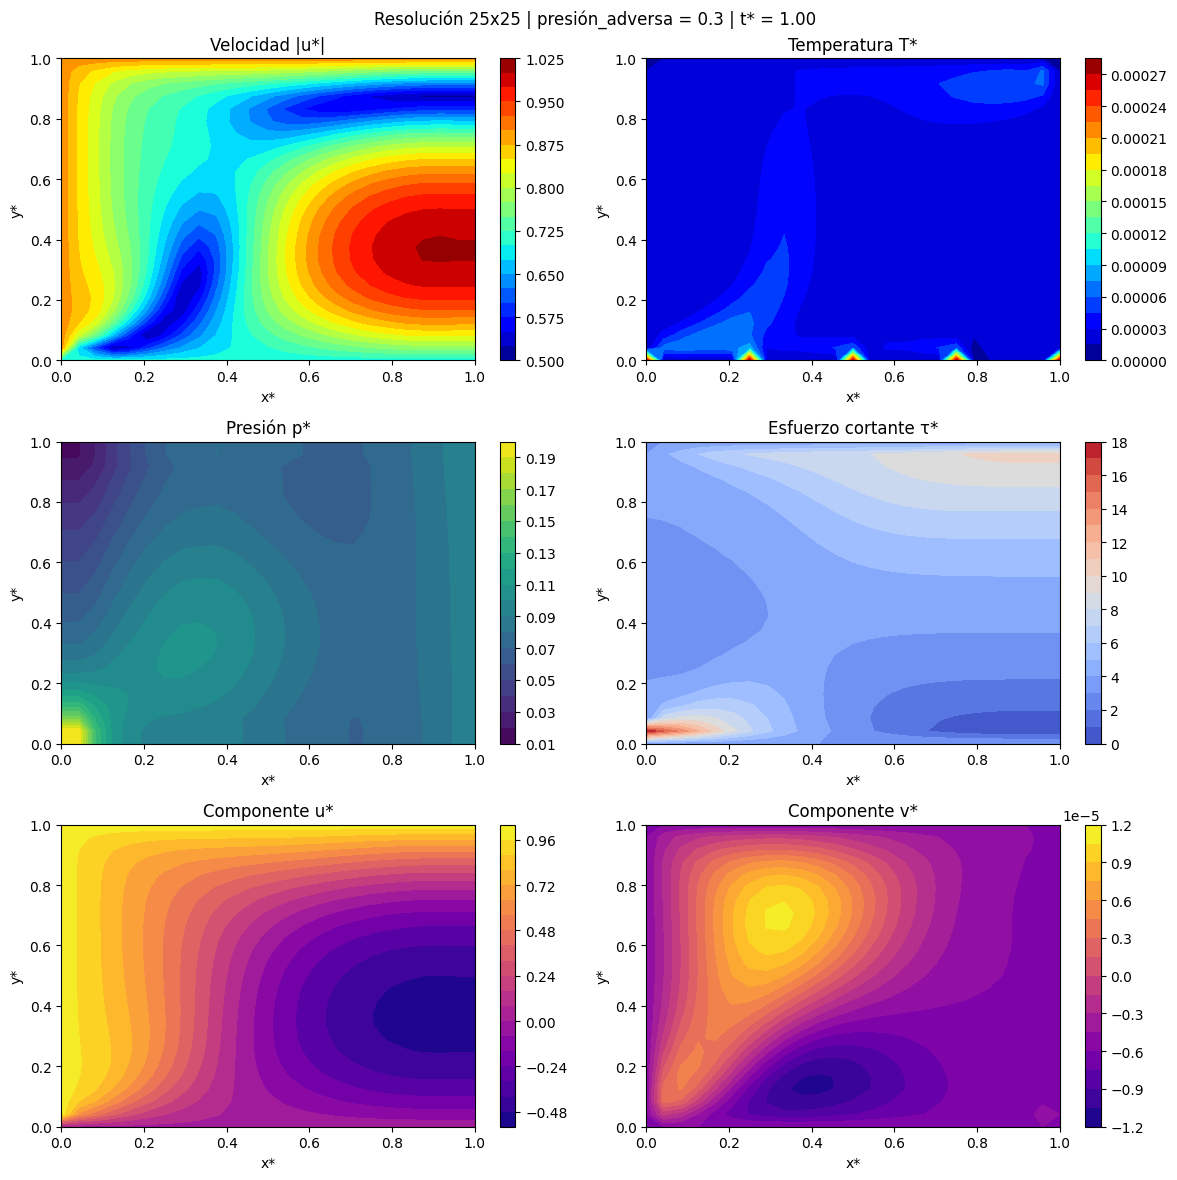

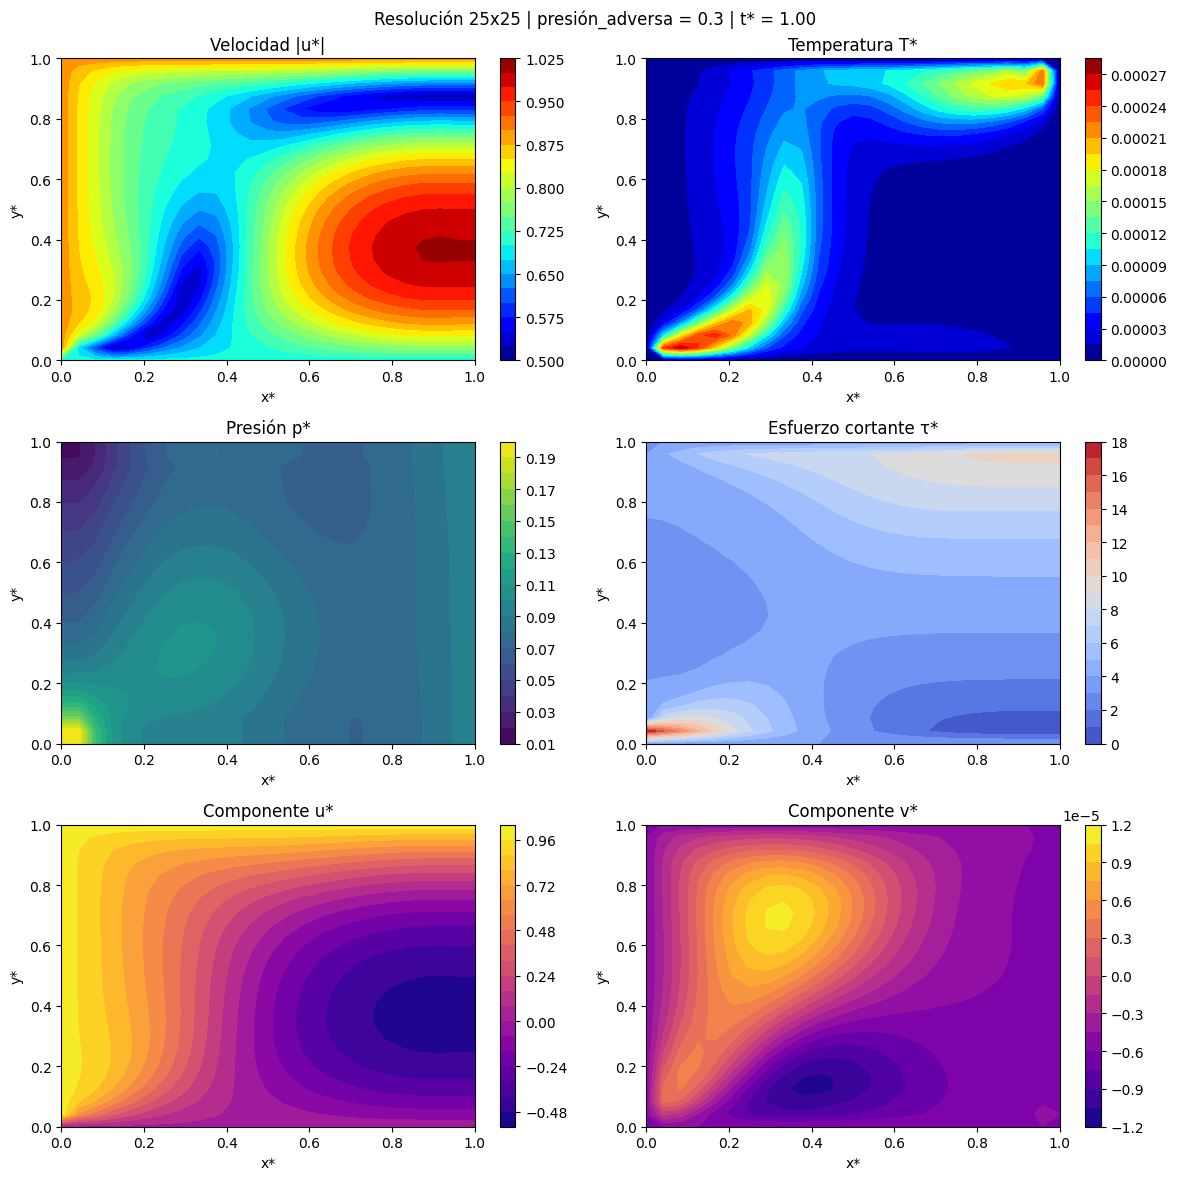

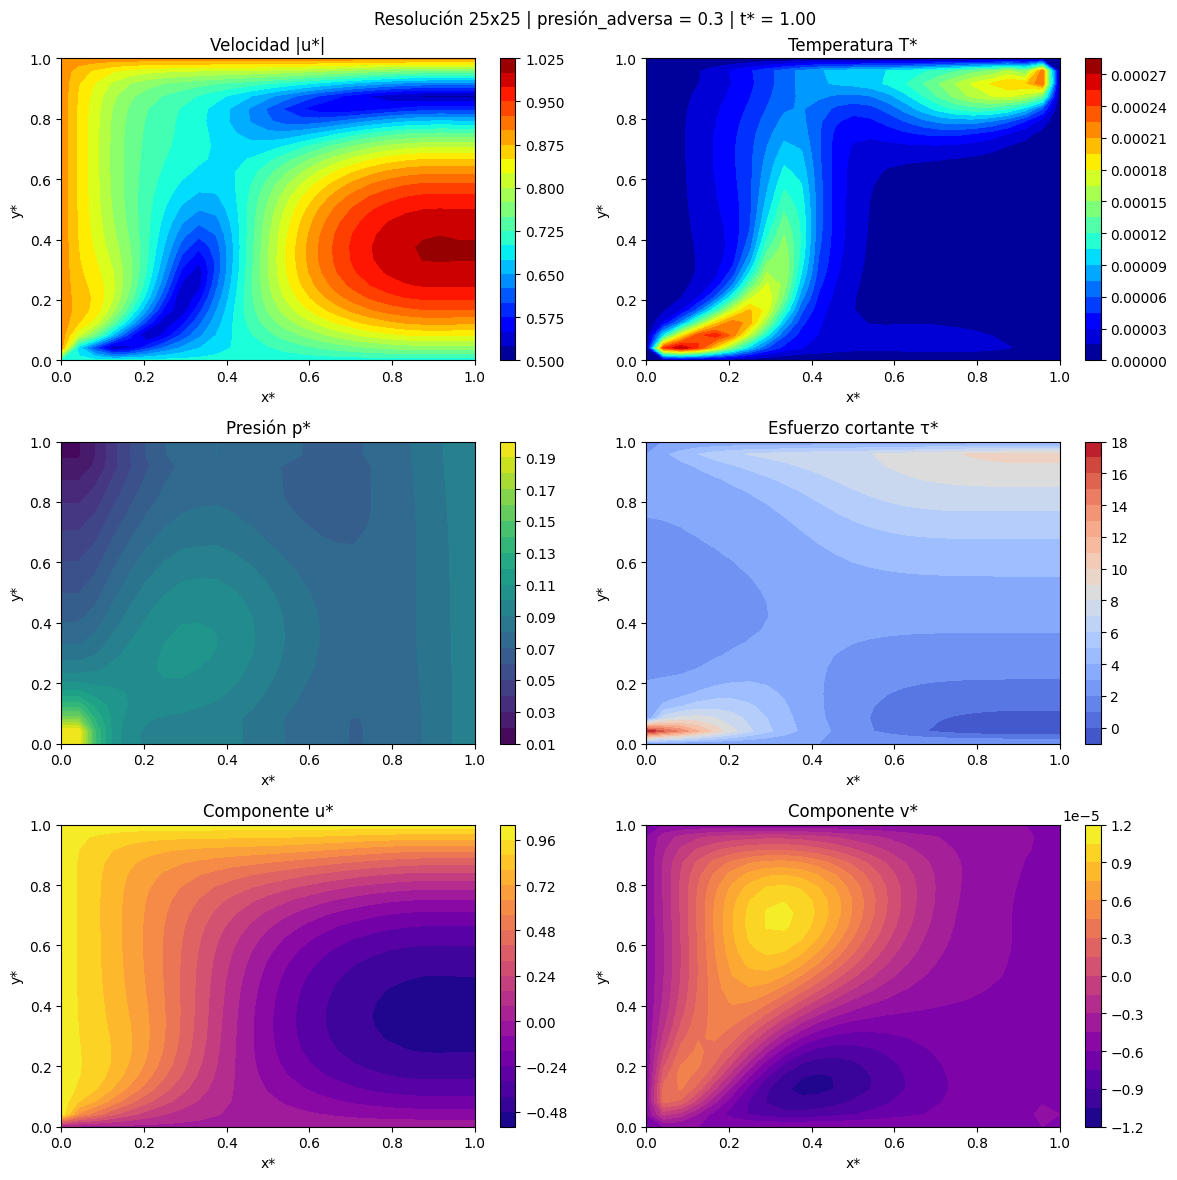

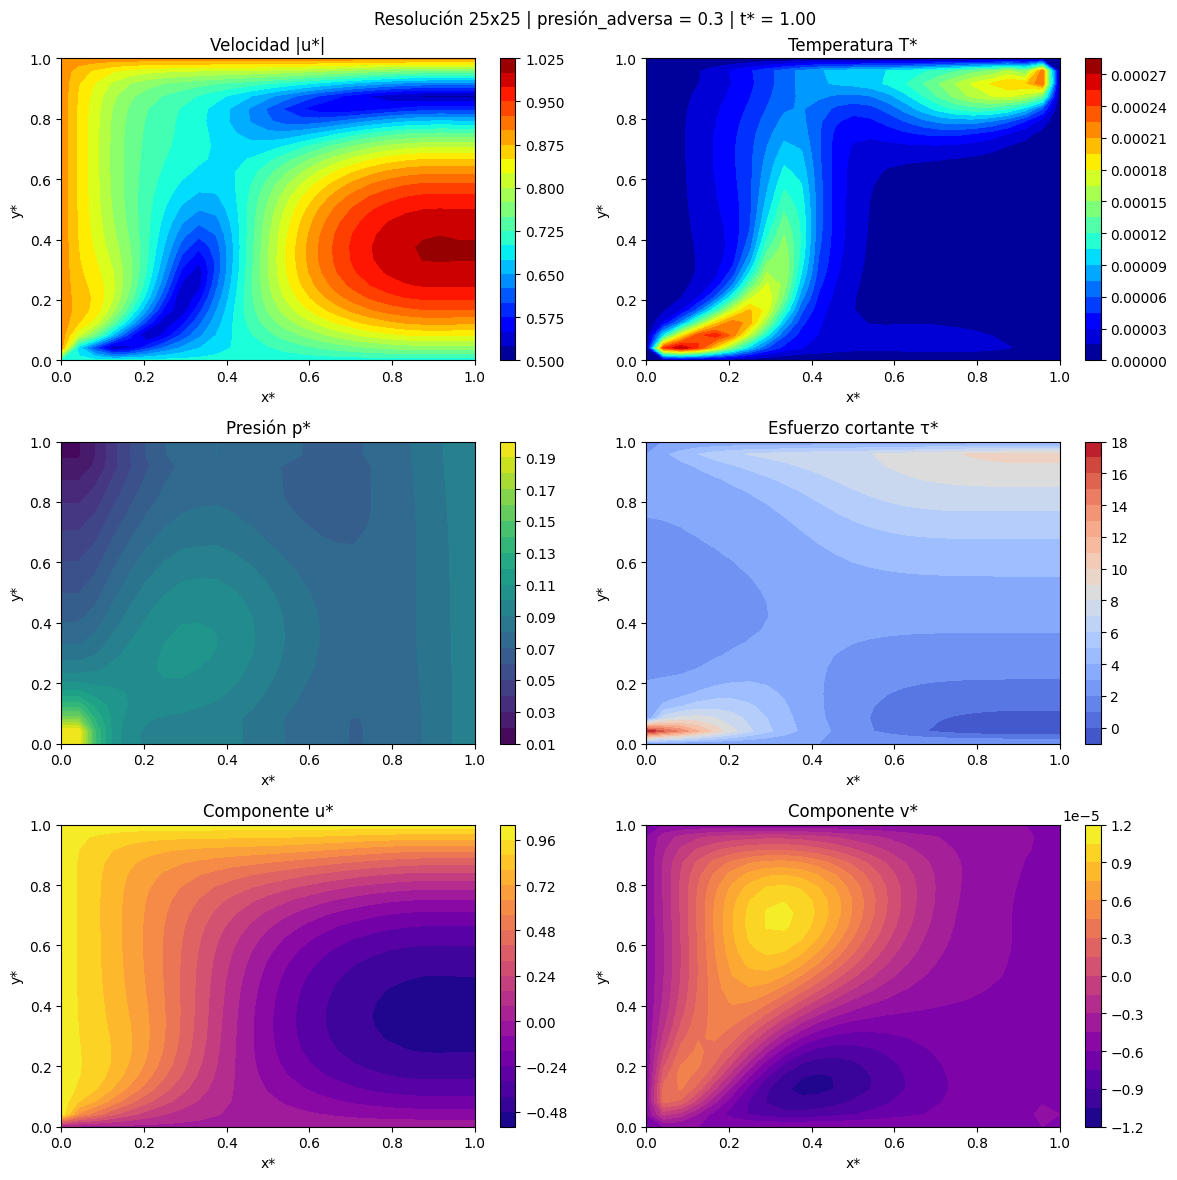

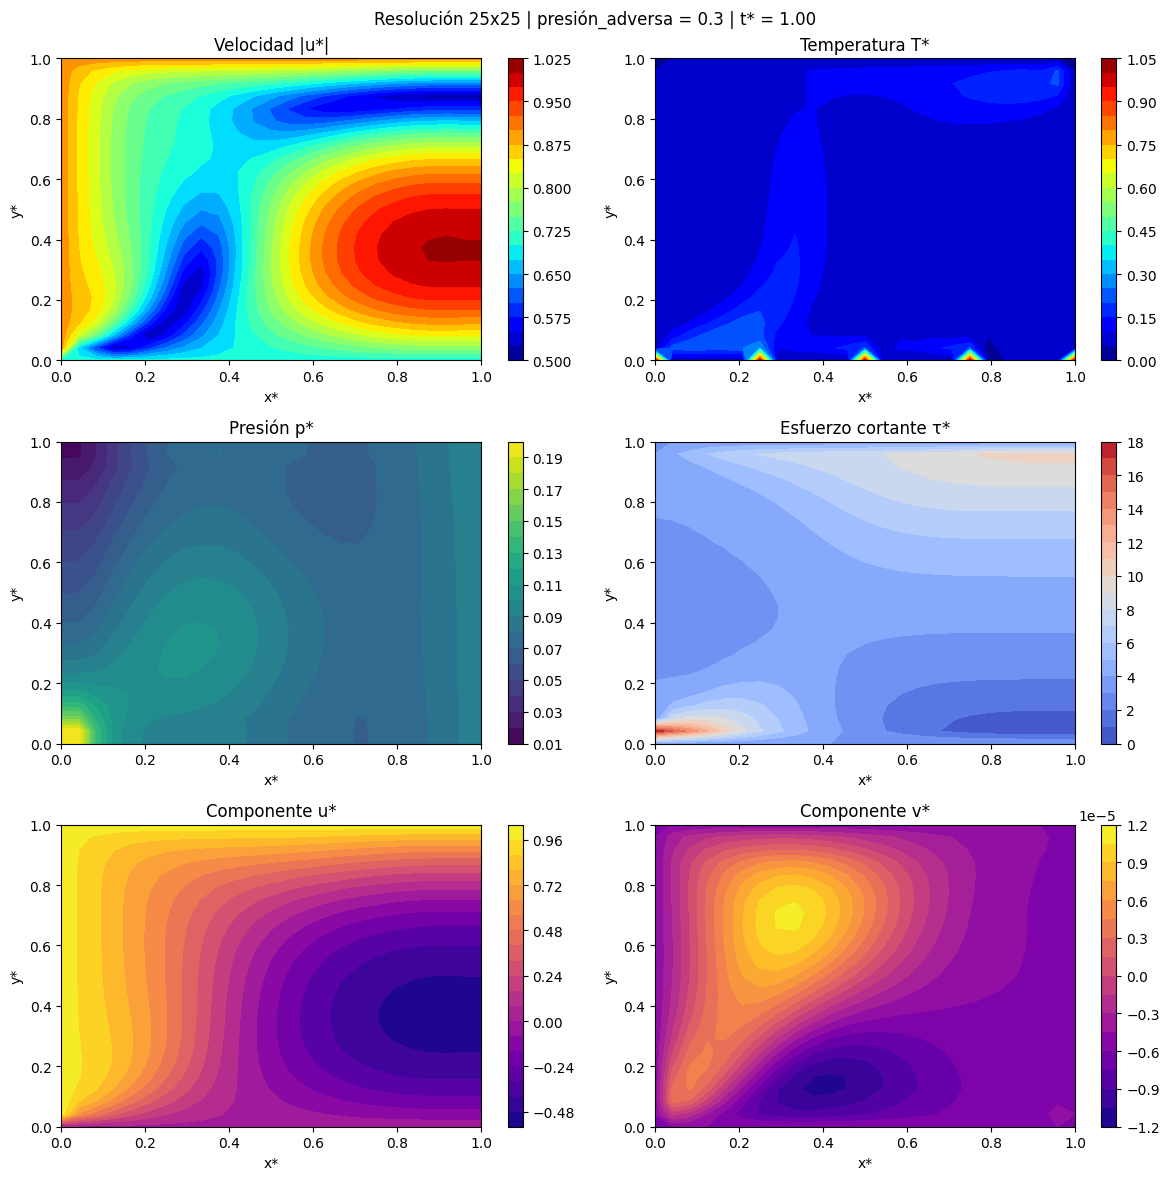

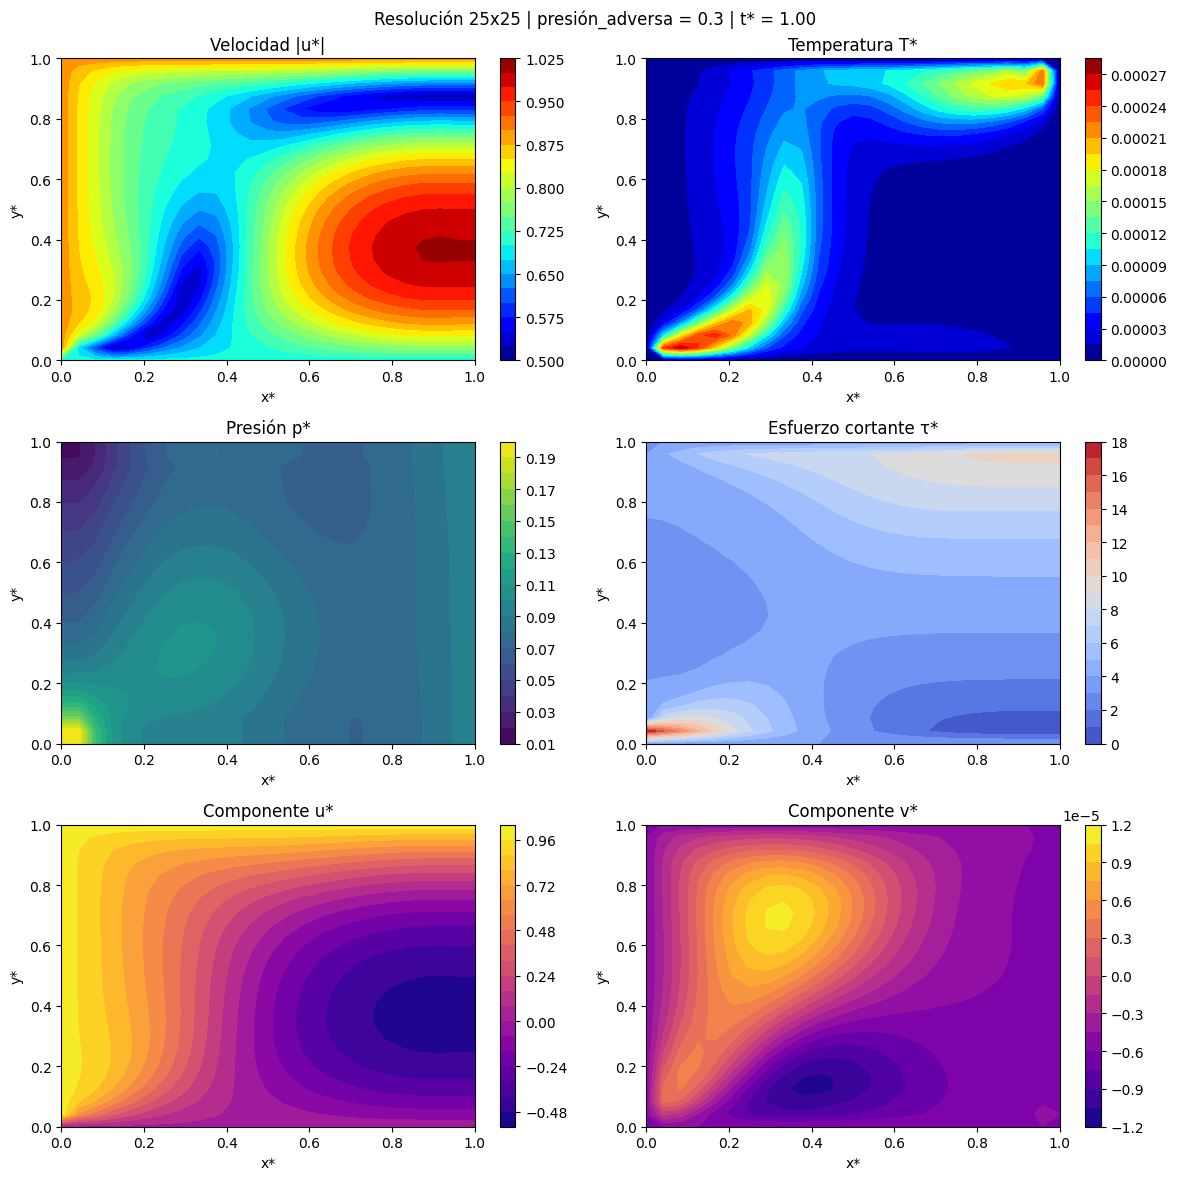

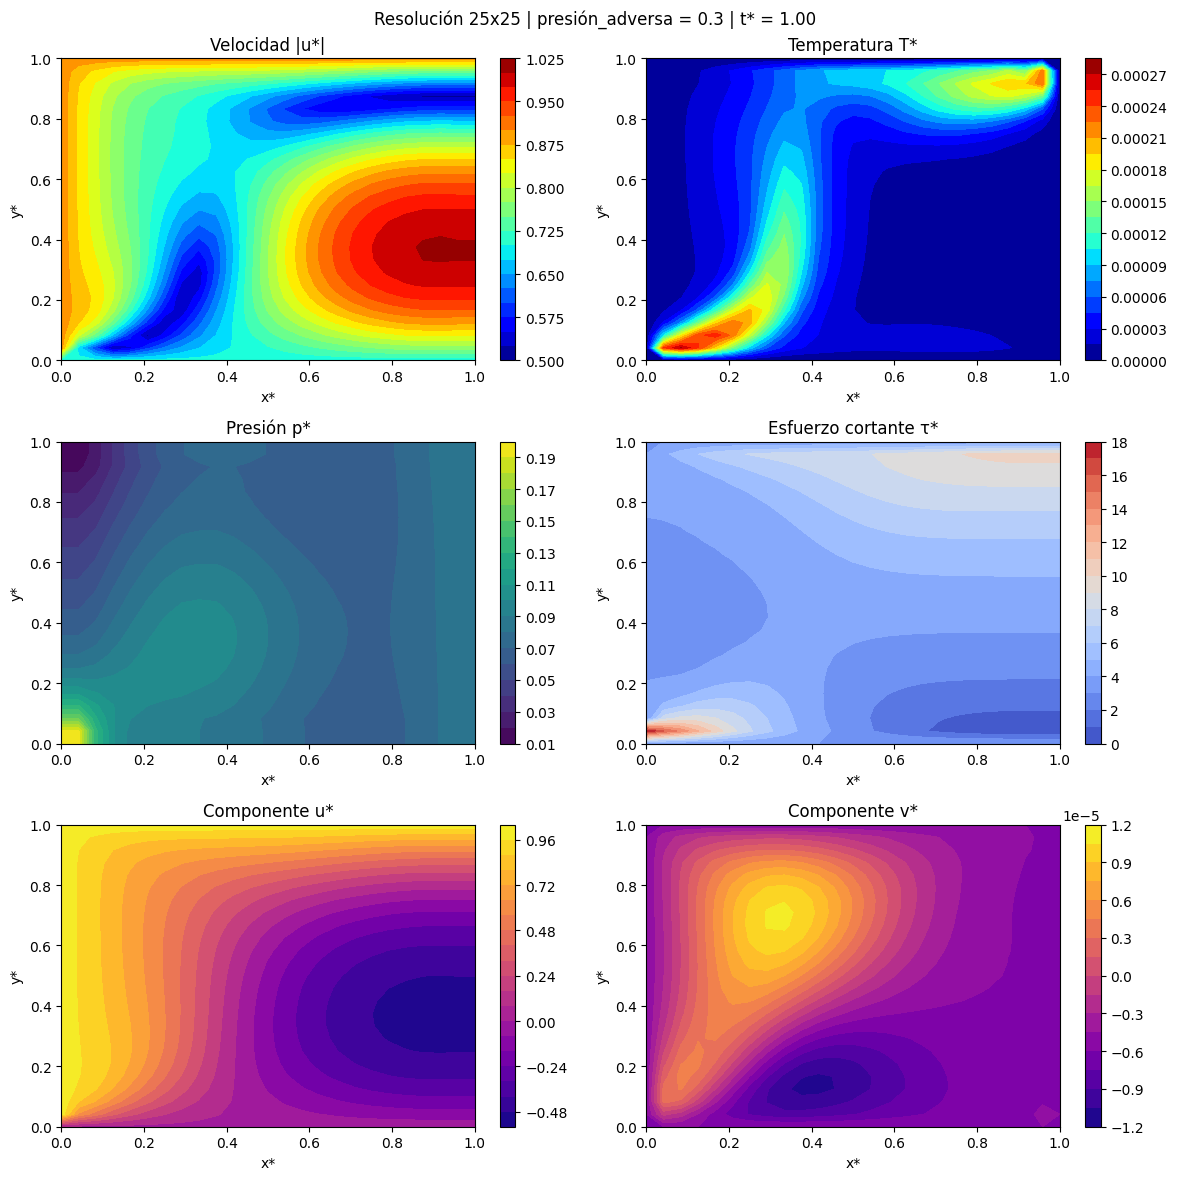

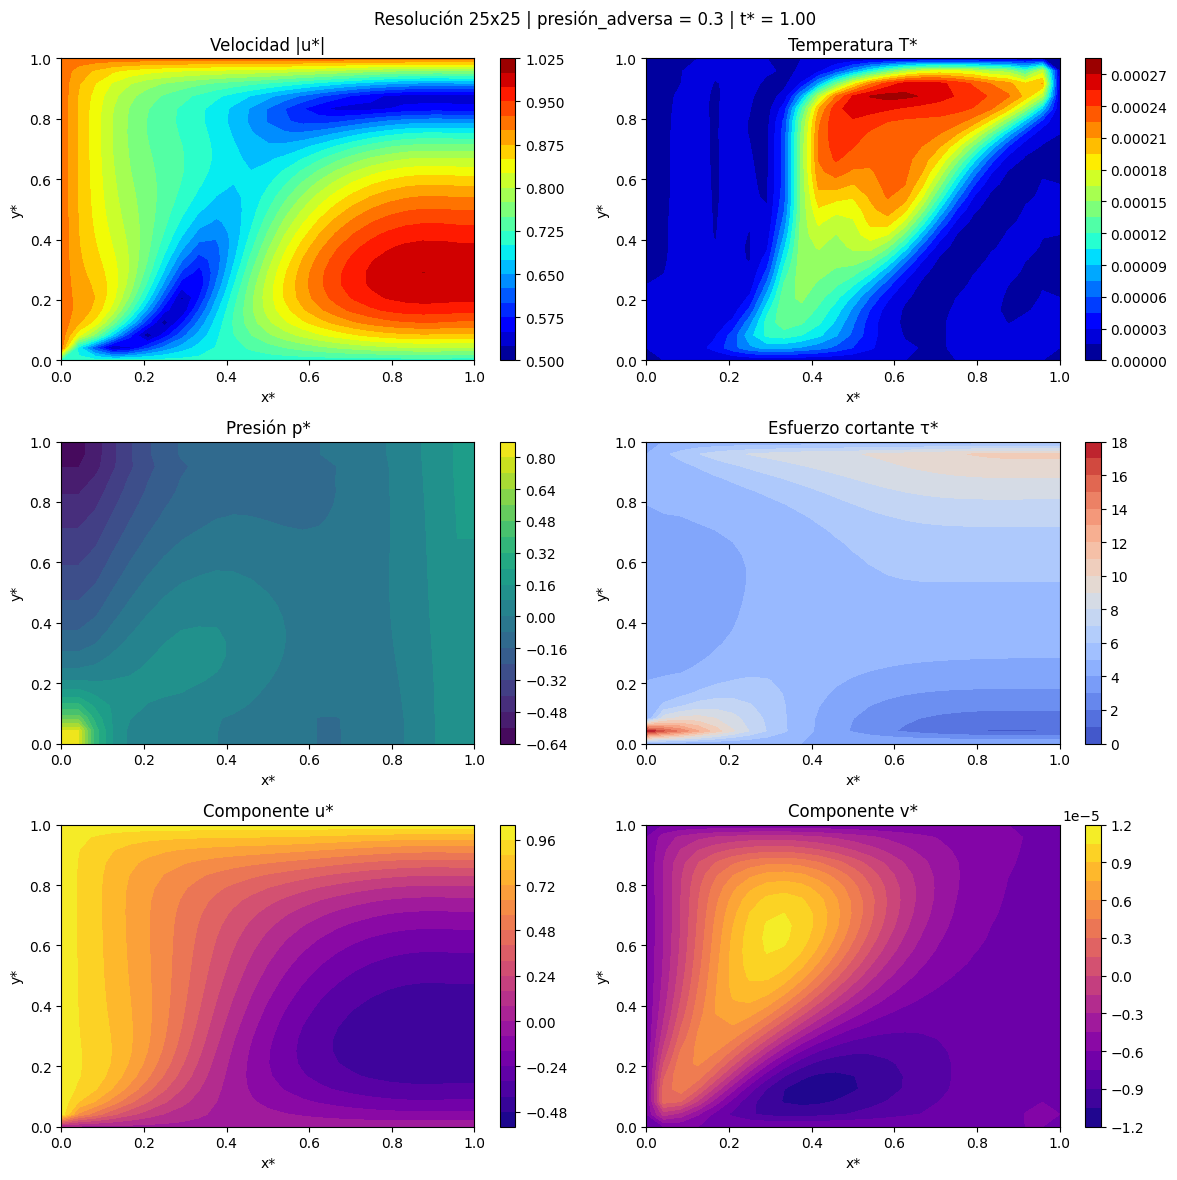

In [15]:
# --- Cargar simulación de referencia ---
with open("DA/25x25/sim_sin_asimilacion.pkl", "rb") as f:
    ref_sim = pickle.load(f)

# --- Función para calcular RMSE total ---
def calcular_rmse(sim, ref, variable="T_history"):
    return np.mean([
        np.sqrt(np.mean((a - b)**2)) for a, b in zip(sim[variable], ref[variable])
    ])

# --- Cargar todos los resultados y seleccionar los mejores ---
def parsear_nombre(nombre):
    metodo, _, obs, freq, vars_tag = nombre.replace(".pkl", "").split("_")
    return {
        "archivo": nombre,
        "metodo": metodo,
        "n_sensores": int(obs.replace("obs", "")),
        "frecuencia": int(freq.replace("freq", "")),
        "variables": ",".join(sorted({"t": "T", "p": "p", "a": "tau"}[c] for c in vars_tag.replace("vars", "")))
    }

base_dir = "DA/25x25"
archivos = [f for f in os.listdir(base_dir) if f.endswith(".pkl") and f != "sim_sin_asimilacion.pkl"]

resultados = []
for archivo in archivos:
    with open(os.path.join(base_dir, archivo), "rb") as f:
        sim = pickle.load(f)
    meta = parsear_nombre(archivo)
    meta["rmse"] = calcular_rmse(sim, ref_sim)
    meta["tiempo"] = sim["asimilacion_time"]
    meta["sim"] = sim
    resultados.append(meta)

import pandas as pd
df = pd.DataFrame(resultados)

# Elegimos los más precisos y más eficientes por método
mas_precisos = df.sort_values('rmse').groupby('metodo').first().reset_index()
mas_eficientes = df.sort_values('tiempo').groupby('metodo').first().reset_index()

# Combinamos ambos para procesar (evitamos duplicados)
combinados = pd.concat([mas_precisos, mas_eficientes]).drop_duplicates(subset=["archivo"])

# --- Función de animación como la tuya ---
def animar_resultados(sim_data, ref_data=None, save_path=None):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    resolucion = X_star.shape[1]
    presion_adversa = sim_data["params"].get("presion_adversa", "N/A")

    fig, axs_grid = plt.subplots(3, 2, figsize=(12, 12))
    axs = axs_grid.flatten()

    titles = [
        'Velocidad |u*|',
        'Temperatura T*',
        'Presión p*',
        'Esfuerzo cortante τ*',
        'Componente u*',
        'Componente v*'
    ]
    cmaps = ['jet', 'jet', 'viridis', 'coolwarm', 'plasma', 'plasma']

    def frame_data(f, dataset):
        return [
            np.sqrt(dataset["u_history"][f]**2 + dataset["v_history"][f]**2),
            dataset["T_history"][f],
            dataset["p_history"][f],
            dataset["tau_history"][f],
            dataset["u_history"][f],
            dataset["v_history"][f],
        ]

    plots = []
    for i, ax in enumerate(axs):
        data = frame_data(0, sim_data)[i]
        plot = ax.contourf(X_star, Y_star, data, levels=20, cmap=cmaps[i])
        plots.append(plot)
        ax.set_title(titles[i])
        ax.set_xlabel("x*")
        ax.set_ylabel("y*")
        plt.colorbar(plot, ax=ax)

    fig.suptitle(f"Resolución {resolucion}x{resolucion} | presión_adversa = {presion_adversa}", fontsize=14)
    plt.tight_layout()

    def update(frame):
        current_data = frame_data(frame, sim_data)
        for i, ax in enumerate(axs):
            for coll in ax.collections:
                coll.remove()
            plots[i] = ax.contourf(X_star, Y_star, current_data[i], levels=20, cmap=cmaps[i])
        fig.suptitle(f"Resolución {resolucion}x{resolucion} | presión_adversa = {presion_adversa} | t* = {frame / len(u_hist):.2f}")
        return axs

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)

    if save_path:
        writer = FFMpegWriter(fps=10, bitrate=1800)
        anim.save(save_path, writer=writer)
        print(f"🎞️ Animación guardada en: {save_path}")

    return anim

# --- Crear y guardar animaciones ---
os.makedirs("animaciones", exist_ok=True)

for i, fila in combinados.iterrows():
    nombre_archivo = f"{fila['metodo']}_preciso" if fila['rmse'] < fila['tiempo'] else f"{fila['metodo']}_eficiente"
    animar_resultados(
        sim_data=fila["sim"],
        ref_data=ref_sim,
        save_path=os.path.join("animaciones", f"{nombre_archivo}.mp4")
    )


In [18]:
# --- Cargar simulación de alta resolución ---
with open("sim_separacion/800x800.pkl", "rb") as f:
    ref_alta = pickle.load(f)

# --- Interpolador general ---
def interpolar_a_resolucion(ref_data, target_shape=(25, 25), variable="T_history"):
    ny, nx = target_shape
    x_old = np.linspace(0, 1, ref_data["X_star"].shape[1])
    y_old = np.linspace(0, 1, ref_data["Y_star"].shape[0])
    x_new = np.linspace(0, 1, nx)
    y_new = np.linspace(0, 1, ny)
    Xn, Yn = np.meshgrid(x_new, y_new)

    interpolados = []
    for frame in ref_data[variable]:
        interpolador = RegularGridInterpolator((y_old, x_old), frame)
        puntos = np.stack([Yn.ravel(), Xn.ravel()], axis=-1)
        frame_interp = interpolador(puntos).reshape((ny, nx))
        interpolados.append(frame_interp)
    return interpolados

# --- Interpolar toda la referencia a 25x25 ---
res_25x25 = (25, 25)
ref_interp = {
    "T_history": interpolar_a_resolucion(ref_alta, res_25x25, "T_history"),
    "p_history": interpolar_a_resolucion(ref_alta, res_25x25, "p_history"),
    "tau_history": interpolar_a_resolucion(ref_alta, res_25x25, "tau_history"),
    "u_history": interpolar_a_resolucion(ref_alta, res_25x25, "u_history"),
    "v_history": interpolar_a_resolucion(ref_alta, res_25x25, "v_history"),
}

# --- Función de RMSE con la nueva referencia interpolada ---
def calcular_rmse(sim, ref, variable="T_history"):
    sim_frames = sim[variable]
    ref_frames = ref[variable]
    n = min(len(sim_frames), len(ref_frames))  # asegura longitud compatible
    return np.mean([
        np.sqrt(np.mean((sim_frames[i] - ref_frames[i]) ** 2))
        for i in range(n)
    ])


In [ ]:
# Reutilizar el bucle para leer resultados desde DA/25x25
resultados = []
carpeta_base = "DA/25x25"

def parsear_nombre(nombre):
    metodo, _, obs, freq, vars_tag = nombre.replace(".pkl", "").split("_")
    return {
        "archivo": nombre,
        "metodo": metodo,
        "n_sensores": int(obs.replace("obs", "")),
        "frecuencia": int(freq.replace("freq", "")),
        "variables": ",".join(sorted({"t": "T", "p": "p", "a": "tau"}[c] for c in vars_tag.replace("vars", "")))
    }

for archivo in os.listdir(carpeta_base):
    if archivo.endswith(".pkl") and archivo != "sim_sin_asimilacion.pkl":
        with open(os.path.join(carpeta_base, archivo), "rb") as f:
            sim = pickle.load(f)
        meta = parsear_nombre(archivo)
        meta["rmse"] = calcular_rmse(sim, ref_interp)
        meta["tiempo"] = sim["asimilacion_time"]
        meta["sim"] = sim
        resultados.append(meta)

df = pd.DataFrame(resultados)
print("\n📊 Resultados de asimilación con referencia interpolada:"  
      "\n", df.to_string(index=False))

/var/folders/lx/vhxvbgp94fj63r8wrldf_13m0000gn/T/ipykernel_1083/1506955292.py:38: RuntimeWarning: overflow encountered in square
  np.sqrt(np.mean((sim_frames[i] - ref_frames[i]) ** 2))
